## Problem 5

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import rpy2.robjects as ro
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

# Load lalonde from Matching package
importr('Matching')
ro.r('data(lalonde, package="Matching")')
lalonde_r = ro.r['lalonde']

with localconverter(default_converter + pandas2ri.converter):
    df = ro.conversion.rpy2py(lalonde_r)

print(df.shape)
print(df.head())

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  


(445, 12)
   age  educ  black  hisp  married  nodegr  re74  re75      re78  u74  u75  \
1   37    11      1     0        1       1   0.0   0.0   9930.05    1    1   
2   22     9      0     1        0       1   0.0   0.0   3595.89    1    1   
3   30    12      1     0        0       0   0.0   0.0  24909.50    1    1   
4   27    11      1     0        0       1   0.0   0.0   7506.15    1    1   
5   33     8      1     0        0       1   0.0   0.0    289.79    1    1   

   treat  
1      1  
2      1  
3      1  
4      1  
5      1  


In [9]:
# Response variable: re78 (real earnings in 1978)
y_col = 're78'
# All other columns as predictors
X_cols = [c for c in df.columns if c != y_col]
print("Predictors:", X_cols)

y = df[y_col].values
X_df = df[X_cols]

Predictors: ['age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 'u74', 'u75', 'treat']


In [ ]:
# Helper functions
def fit_subset(X_df, y, cols):
    X = X_df[list(cols)].values
    n, p = X.shape
    # Add intercept manually
    X_int = np.column_stack([np.ones(n), X])
    beta, _, _, _ = np.linalg.lstsq(X_int, y, rcond=None)
    yhat = X_int @ beta
    rss = np.sum((y - yhat)**2)
    return rss, beta, X_int, yhat

def compute_hat_diagonal(X_int):
    Q, _ = np.linalg.qr(X_int)
    return np.sum(Q**2, axis=1)  # diagonal of hat matrix

def aic(rss, n, p):
    # AIC = n*log(RSS/n) + 2*(p+1), where p+1 counts intercept
    return n * np.log(rss / n) + 2 * (p + 1)

def bic(rss, n, p):
    return n * np.log(rss / n) + np.log(n) * (p + 1)

def press(y, yhat, h):
    residuals = y - yhat
    return np.sum((residuals / (1 - h))**2)

def gcv(rss, n, p):
    # GCV = (RSS/n) / (1 - (p+1)/n)^2
    return (rss / n) / (1 - (p + 1) / n)**2

In [11]:
n = len(y)
all_cols = X_cols
max_size = len(all_cols)

results = []  # list of dicts

for size in range(1, max_size + 1):
    best = None
    for cols in combinations(all_cols, size):
        rss, beta, X_int, yhat = fit_subset(X_df, y, cols)
        h = compute_hat_diagonal(X_int)
        p = size  # number of predictors (excluding intercept)
        row = {
            'size': size,
            'cols': cols,
            'rss': rss,
            'aic': aic(rss, n, p),
            'bic': bic(rss, n, p),
            'press': press(y, yhat, h),
            'gcv': gcv(rss, n, p),
        }
        # Keep only best RSS per size (best subset)
        if best is None or rss < best['rss']:
            best = row
    results.append(best)

results_df = pd.DataFrame(results)
print(results_df[['size', 'rss', 'aic', 'bic', 'press', 'gcv']])

    size           rss          aic          bic         press           gcv
0      1  1.917764e+10  7826.626849  7834.822998  1.936203e+10  4.348583e+07
1      2  1.890637e+10  7822.287272  7834.581495  1.915607e+10  4.306492e+07
2      3  1.866028e+10  7818.457026  7834.849323  1.898138e+10  4.269736e+07
3      4  1.853021e+10  7817.344268  7837.834640  1.904844e+10  4.259268e+07
4      5  1.846226e+10  7817.709443  7842.297889  1.903977e+10  4.263004e+07
5      6  1.844828e+10  7819.372367  7848.058887  1.916328e+10  4.279250e+07
6      7  1.839347e+10  7820.048310  7852.832904  1.925513e+10  4.286085e+07
7      8  1.839041e+10  7821.974400  7858.857069  1.932720e+10  4.305053e+07
8      9  1.838958e+10  7823.954145  7864.934888  1.941543e+10  4.324673e+07
9     10  1.838885e+10  7825.936639  7871.015456  1.950299e+10  4.344454e+07
10    11  1.838884e+10  7827.936405  7877.113296  1.960120e+10  4.364542e+07


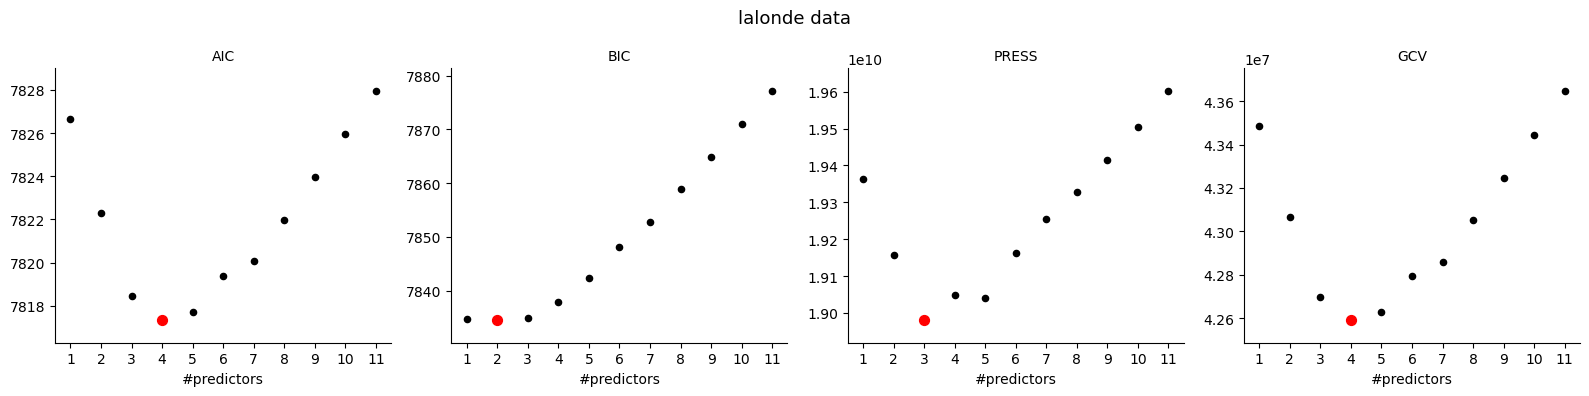

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('lalonde data', fontsize=13)

metrics = ['aic', 'bic', 'press', 'gcv']
labels  = ['AIC', 'BIC', 'PRESS', 'GCV']

for ax, metric, label in zip(axes, metrics, labels):
    vals = results_df[metric].values
    sizes = results_df['size'].values
    idx_min = np.argmin(vals)

    ax.scatter(sizes, vals, color='black', s=20, zorder=2)
    ax.scatter(sizes[idx_min], vals[idx_min], color='red', s=50, zorder=3)

    # Tight y-axis like Figure 13.4
    pad = (vals.max() - vals.min()) * 0.1
    ax.set_ylim(vals.min() - pad, vals.max() + pad)

    ax.set_title(label, fontsize=10)
    ax.set_xlabel('#predictors')
    ax.set_xticks(sizes)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('lalonde_best_subset.png', dpi=150)
plt.show()

In [15]:
selected = {}
for metric in ['aic', 'bic', 'press', 'gcv']:
    idx = results_df[metric].idxmin()
    row = results_df.loc[idx]
    selected[metric] = (int(row['size']), row['cols'])

print("Selected Models:")
for metric, (size, cols) in selected.items():
    print(f"{metric.upper():>5}: {size} predictor(s) -> {list(cols)}")

Selected Models:
  AIC: 4 predictor(s) -> ['educ', 'black', 're74', 'treat']
  BIC: 2 predictor(s) -> ['black', 'treat']
PRESS: 3 predictor(s) -> ['educ', 'black', 'treat']
  GCV: 4 predictor(s) -> ['educ', 'black', 're74', 'treat']


Each panel plots the best-subset criterion value against model size, with the minimum marked in red. All four curves share the same qualitative shape: a sharp drop initially as the most informative predictors enter, followed by a clear upturn once the useful signal is exhausted and additional predictors only add noise. BIC selects the most parsimonious model (2 predictors) due to its stronger $\log n$ penalty. AIC and GCV agree on 4 predictors, while PRESS lands at 3, dropping `re74` as marginally unstable across folds.

The best subset search evaluated all possible subsets of the 11 predictors, keeping the subset with lowest RSS at each size. The four criteria then pick their preferred model size by trading off fit against complexity.

`treat` and `black` appear in every selected model. A reasonable choice is the 3–4 predictor model containing `treat`, `black`, `educ`, and possibly `re74`, with BIC being the only criterion that argues for going smaller.

# Problem 6

I will augment the Boston housing design matrix with noise columns drawn from a Uniform(−1, 1) distribution, differing from the Gaussian N(0,1) noise in Section 15.4. Uniform noise has the same zero mean and is uncorrelated with the response by construction, but has bounded support and lighter tails. I consider two settings: $p = n = 506$ and $p = 2n = 1012$ added noise columns, using the same 90/10 train/test split throughout.

In [17]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

importr('mlbench')
ro.r('data(BostonHousing)')
boston_r = ro.r['BostonHousing']
with localconverter(ro.default_converter + pandas2ri.converter):
    boston = ro.conversion.rpy2py(boston_r)

y = boston['medv'].values
X = boston.drop(columns=['medv'])
X = pd.get_dummies(X, drop_first=True).astype(float).values
n, p_orig = X.shape
print(f"n={n}, p_orig={p_orig}")

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  


n=506, p_orig=13


In [18]:
np.random.seed(230)
n_train = int(np.floor(n * 0.9))
train_idx = np.random.choice(n, n_train, replace=False)
test_idx  = np.setdiff1d(np.arange(n), train_idx)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize (ridge/lasso need it)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [20]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# OLS
ols = LinearRegression().fit(X_train_s, y_train)
mse_ols_base = mse(y_test, ols.predict(X_test_s))

# Ridge (CV over lambdas)
ridge_cv = RidgeCV(alphas=np.linspace(0.01, 5, 501)).fit(X_train_s, y_train)
mse_ridge_base = mse(y_test, ridge_cv.predict(X_test_s))

# Lasso (CV)
lasso_cv = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X_train_s, y_train)
mse_lasso_base = mse(y_test, lasso_cv.predict(X_test_s))

print("Baseline (original data):")
print(f"OLS:   {mse_ols_base:.4f}")
print(f"Ridge: {mse_ridge_base:.4f}")
print(f"Lasso: {mse_lasso_base:.4f}")

Baseline (original data):
OLS:   25.3726
Ridge: 24.9758
Lasso: 24.8516


In [26]:
# Noise DGP: Uniform(-1, 1)  [different from book's Gaussian]
np.random.seed(230)
p_noise_1 = n  # p = n = 506

noise_train_1 = np.random.uniform(-1, 1, size=(n_train, p_noise_1))
noise_test_1  = np.random.uniform(-1, 1, size=(len(test_idx), p_noise_1))

Xn1_train = np.hstack([X_train_s, noise_train_1])
Xn1_test  = np.hstack([X_test_s,  noise_test_1])

# OLS: p=n so underdetermined — use lstsq minimum norm solution
ols_n1 = LinearRegression().fit(Xn1_train, y_train)
mse_ols_n1 = mse(y_test, ols_n1.predict(Xn1_test))

ridge_cv_n1 = RidgeCV(alphas=np.linspace(1, 150, 500)).fit(Xn1_train, y_train)
mse_ridge_n1 = mse(y_test, ridge_cv_n1.predict(Xn1_test))

lasso_cv_n1 = LassoCV(cv=5, random_state=0, max_iter=50000,
                       alphas=np.logspace(-2, 2, 100)).fit(Xn1_train, y_train)
mse_lasso_n1 = mse(y_test, lasso_cv_n1.predict(Xn1_test))

coef_lasso_n1 = lasso_cv_n1.coef_
coef_ridge_n1 = ridge_cv_n1.coef_

print("p = n noise columns:")
print(f"OLS:   {mse_ols_n1:.4f}")
print(f"Ridge: {mse_ridge_n1:.4f}")
print(f"Lasso: {mse_lasso_n1:.4f}")

p = n noise columns:
OLS:   185.0104
Ridge: 32.8060
Lasso: 27.7488


In [27]:
np.random.seed(231)
p_noise_2 = 2 * n

noise_train_2 = np.random.uniform(-1, 1, size=(n_train, p_noise_2))
noise_test_2  = np.random.uniform(-1, 1, size=(len(test_idx), p_noise_2))

Xn2_train = np.hstack([X_train_s, noise_train_2])
Xn2_test  = np.hstack([X_test_s,  noise_test_2])

# OLS is now heavily underdetermined
ols_n2 = LinearRegression().fit(Xn2_train, y_train)
mse_ols_n2 = mse(y_test, ols_n2.predict(Xn2_test))

ridge_cv_n2 = RidgeCV(alphas=np.linspace(1, 150, 500)).fit(Xn2_train, y_train)
mse_ridge_n2 = mse(y_test, ridge_cv_n2.predict(Xn2_test))

lasso_cv_n2 = LassoCV(cv=5, random_state=0, max_iter=50000,
                       alphas=np.logspace(-2, 2, 100)).fit(Xn2_train, y_train)
mse_lasso_n2 = mse(y_test, lasso_cv_n2.predict(Xn2_test))

coef_lasso_n2 = lasso_cv_n2.coef_
coef_ridge_n2 = ridge_cv_n2.coef_

print("p = 2n noise columns:")
print(f"OLS:   {mse_ols_n2:.4f}")
print(f"Ridge: {mse_ridge_n2:.4f}")
print(f"Lasso: {mse_lasso_n2:.4f}")

p = 2n noise columns:
OLS:   42.6968
Ridge: 33.1530
Lasso: 24.4820


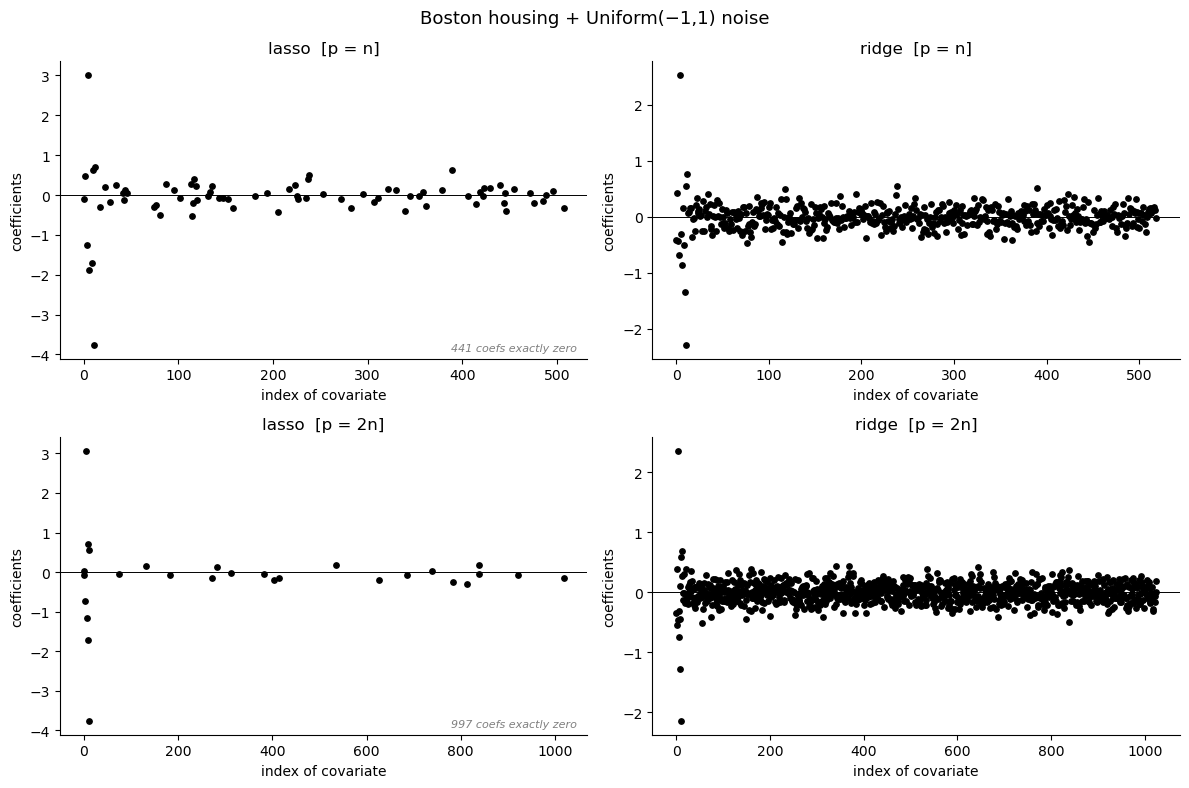

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Boston housing + Uniform(−1,1) noise', fontsize=13)

configs = [
    (coef_lasso_n1, 'lasso  [p = n]',  axes[0,0]),
    (coef_ridge_n1, 'ridge  [p = n]',  axes[0,1]),
    (coef_lasso_n2, 'lasso  [p = 2n]', axes[1,0]),
    (coef_ridge_n2, 'ridge  [p = 2n]', axes[1,1]),
]

for coef, title, ax in configs:
    nonzero = np.abs(coef) > 1e-6
    ax.scatter(np.where(nonzero)[0], coef[nonzero], s=15, color='black', zorder=2)
    ax.axhline(0, color='black', linewidth=0.7)
    n_zero = np.sum(~nonzero)
    if n_zero > 0:
        ax.text(0.98, 0.02, f'{n_zero} coefs exactly zero',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, color='grey', style='italic')
    ax.set_title(title)
    ax.set_xlabel('index of covariate')
    ax.set_ylabel('coefficients')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('boston_noise_coefs.png', dpi=150)
plt.show()

In [29]:
summary = pd.DataFrame({
    'Setting':   ['Original', 'p = n noise', 'p = 2n noise'],
    'OLS':   [mse_ols_base,  mse_ols_n1,  mse_ols_n2],
    'Ridge': [mse_ridge_base, mse_ridge_n1, mse_ridge_n2],
    'Lasso': [mse_lasso_base, mse_lasso_n1, mse_lasso_n2],
})
print(summary.to_string(index=False))


     Setting        OLS     Ridge     Lasso
    Original  25.372558 24.975773 24.851620
 p = n noise 185.010442 32.806005 27.748807
p = 2n noise  42.696783 33.152980 24.481995


With the original predictors all three methods perform similarly, consistent with Section 15.4. Adding noise hits OLS hardest — MSE explodes to 185 at $p = n$ as the design matrix becomes nearly singular. Ridge and Lasso stay stable throughout. Lasso is the clear winner: it zeros out 441/519 and 997/1025 coefficients in the two noise settings respectively, effectively ignoring the noise and maintaining near-baseline MSE.